In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import uproot
import glob
import os

In [8]:
def as_array(inpath,folder, varname, cut, nchunks):
    if nchunks is not None:
        files = glob.glob(os.path.join(os.path.abspath(inpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inpath), folder, "*.root:events" )

    try: 
        # awkward array instead of numpy -> allows variable length elements
        #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
        arr = uproot.concatenate( path, expressions=varname, cut=cut)
    except:
        branches = get_list_of_branches(folder)
        print( f"Branches found in files at path {folder}:" )
        for br in branches:
            print('  ', br)
        raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

    # Return awkward array as a flattened ndarray
    return arr

In [76]:
input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/full_prelim_cuts"
vars = ["Rec_vtx_d2PV","Rec_vtx_d2PV_err","Rec_vtx_normd2PV","Rec_vtx_isPV","Rec_vtx_d2PV_x","Rec_vtx_d2PV_y","Rec_vtx_d2PV_z","Rec_vtx_normd2PV_x","Rec_vtx_normd2PV_y","Rec_vtx_normd2PV_z","Rec_vtx_chi2","Rec_vtx_xerr",
"Rec_vtx_yerr", "Rec_vtx_zerr","Rec_vtx_x", "Rec_vtx_y","Rec_vtx_z"]
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]
df_dict={}
for decay in decay_list:
    df_dict[decay] = as_array(inpath=input,folder=decay, varname=vars, cut=cuts, nchunks=12)

In [77]:
dict_for_df_perdecay = {}
for sample in decay_list:
    dict_for_df={}
    for variable in vars:
         dict_for_df[variable] = ak.to_numpy(ak.ravel(df_dict[sample][variable]))
    dict_for_df_perdecay[sample] = dict_for_df

In [78]:
samples_dfs={}
PVs_df = {}
for sample in decay_list:
    # Create a DataFrame from the dictionary
    df = pd.DataFrame(dict_for_df_perdecay[sample])
    samples_dfs[sample] = df[df["Rec_vtx_isPV"]==0]
    PVs_df[sample] = df[df["Rec_vtx_isPV"]==1]
    


0.0
6.163955040111938e-07
1.3413042574338436e-06
4.900027195150933e-06
0.0


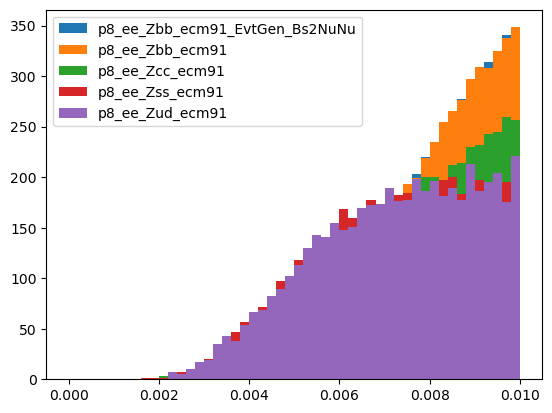

In [79]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_d2PV_err"],bins=50,label=sample,density=True,range=(0,0.01))
    df_nonPV = samples_dfs[sample]
    print(len(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0])/len(df_nonPV))
plt.legend()

In [80]:
for sample in ["p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91"]:
    print(sample)
    df_nonPV = samples_dfs[sample]
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_d2PV"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_normd2PV"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_xerr"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_yerr"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_zerr"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_x"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_y"])
    print(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_z"])
    #plt.hist(df_nonPV[df_nonPV["Rec_vtx_d2PV_err"]==0]["Rec_vtx_d2PV"],bins=50,label=sample,density=True)
#plt.legend()

p8_ee_Zbb_ecm91
153428    23953.921875
Name: Rec_vtx_d2PV, dtype: float32
153428    inf
Name: Rec_vtx_normd2PV, dtype: float32
153428   NaN
Name: Rec_vtx_xerr, dtype: float32
153428   NaN
Name: Rec_vtx_yerr, dtype: float32
153428   NaN
Name: Rec_vtx_zerr, dtype: float32
153428   -8677.660156
Name: Rec_vtx_x, dtype: float32
153428   -17617.091797
Name: Rec_vtx_y, dtype: float32
153428   -13715.652344
Name: Rec_vtx_z, dtype: float32
p8_ee_Zcc_ecm91
139813    2926.927246
Name: Rec_vtx_d2PV, dtype: float32
139813    inf
Name: Rec_vtx_normd2PV, dtype: float32
139813   NaN
Name: Rec_vtx_xerr, dtype: float32
139813   NaN
Name: Rec_vtx_yerr, dtype: float32
139813   NaN
Name: Rec_vtx_zerr, dtype: float32
139813    1661.298706
Name: Rec_vtx_x, dtype: float32
139813   -1502.389648
Name: Rec_vtx_y, dtype: float32
139813   -1883.713989
Name: Rec_vtx_z, dtype: float32
p8_ee_Zss_ecm91
275533      550.632202
410555    21822.478516
Name: Rec_vtx_d2PV, dtype: float32
275533    inf
410555    inf
Name: Re

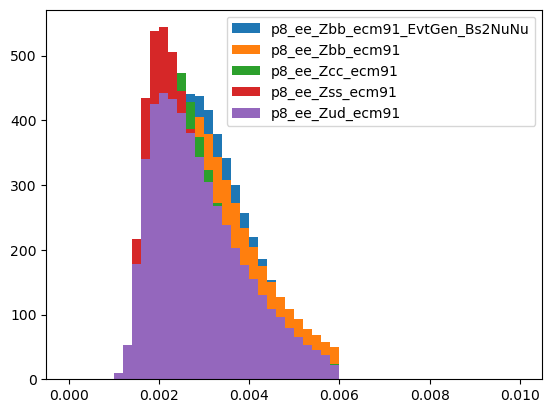

In [81]:
for sample in decay_list:
    plt.hist(PVs_df[sample]["Rec_vtx_xerr"],bins=50,label=sample,density=True,range=(0,0.01))
    df_PV = PVs_df[sample]
plt.legend()

2.379974e-05
2.3799865e-05
2.3799541e-05
2.379973e-05
2.3798797e-05


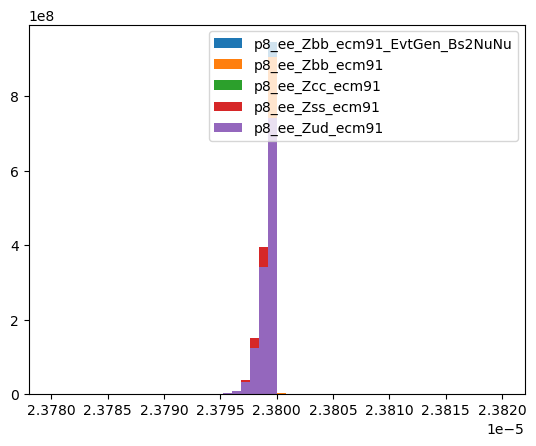

In [82]:
for sample in decay_list:
    plt.hist(PVs_df[sample]["Rec_vtx_yerr"],bins=50,label=sample,density=True,range=(0.00002378,0.00002382))
    df_PV = PVs_df[sample]
    print(PVs_df[sample]["Rec_vtx_yerr"][0])
plt.legend()

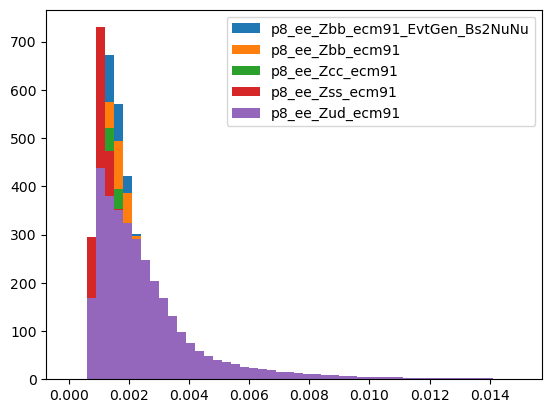

In [83]:
for sample in decay_list:
    plt.hist(PVs_df[sample]["Rec_vtx_zerr"],bins=50,label=sample,density=True,range=(0,0.015))
    df_PV = PVs_df[sample]
plt.legend()

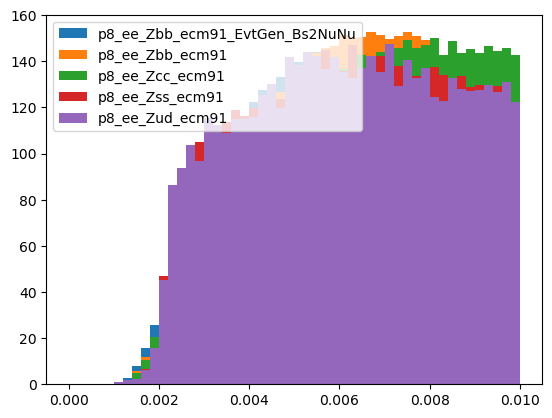

In [84]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_xerr"],bins=50,label=sample,density=True,range=(0,0.01))
plt.legend()

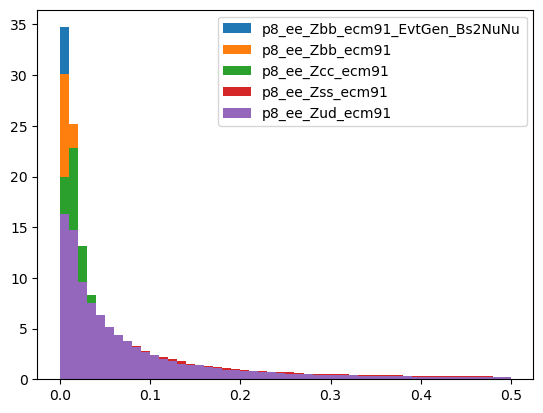

In [85]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_xerr"],bins=50,label=sample,density=True,range=(0,0.5))
plt.legend()

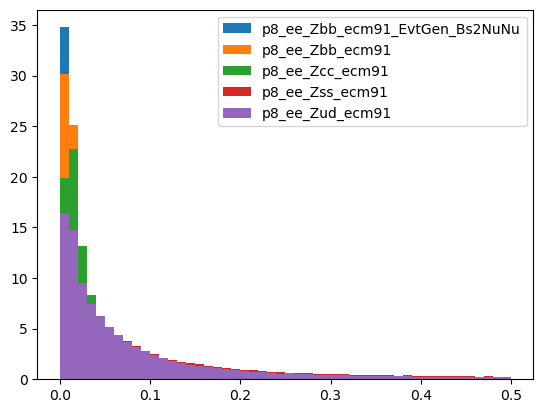

In [86]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_yerr"],bins=50,label=sample,density=True,range=(0,0.5))
plt.legend()

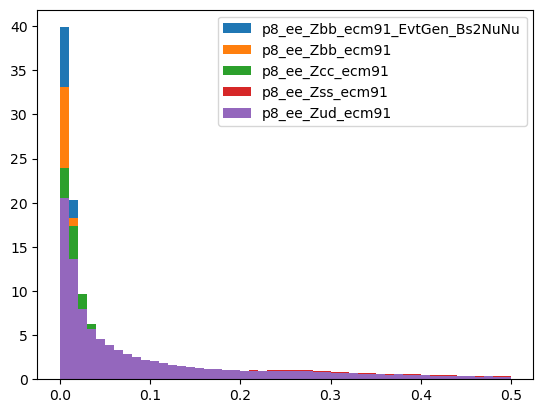

In [87]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_zerr"],bins=50,label=sample,density=True,range=(0,0.5))
plt.legend()

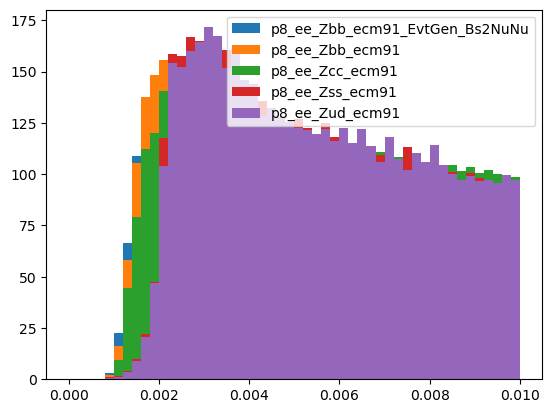

In [88]:
for sample in decay_list:
    plt.hist(samples_dfs[sample]["Rec_vtx_zerr"],bins=50,label=sample,density=True,range=(0,0.01))
plt.legend()